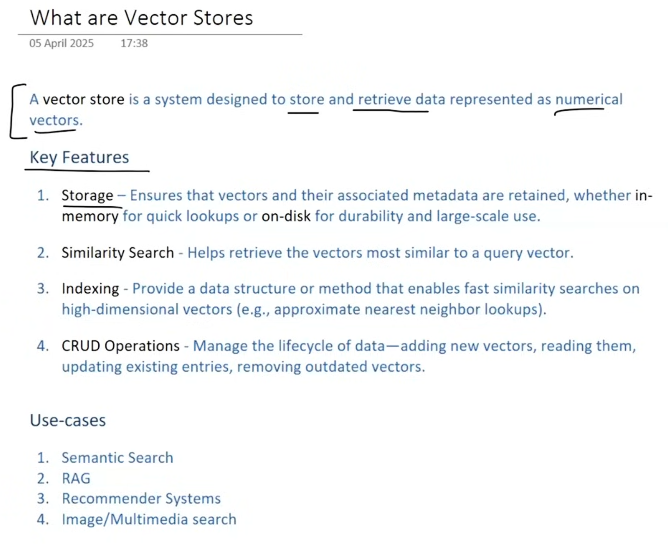
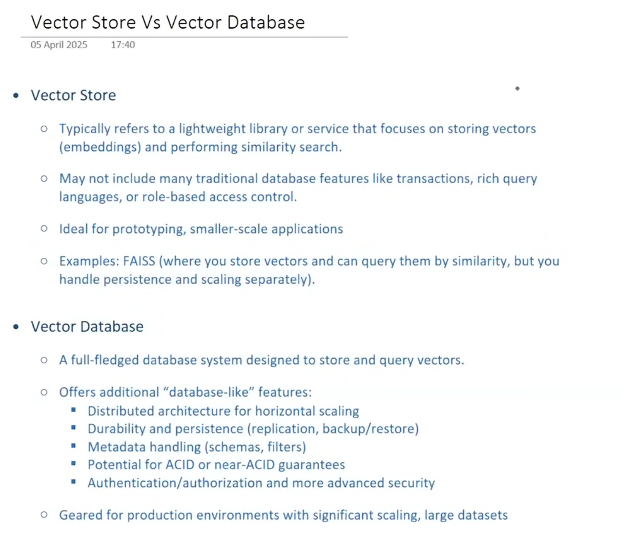
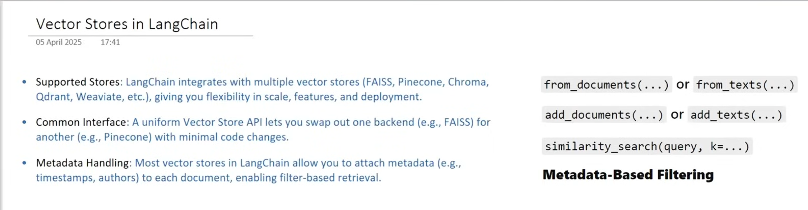

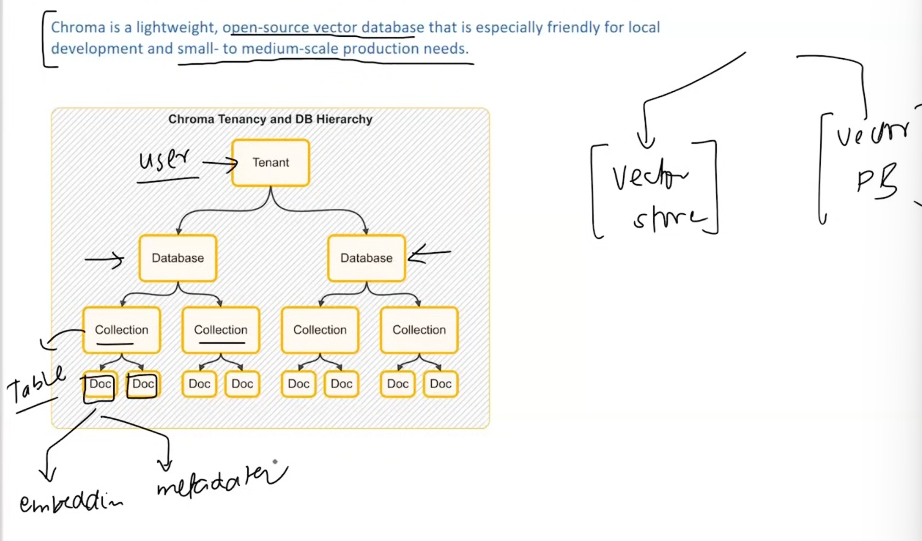
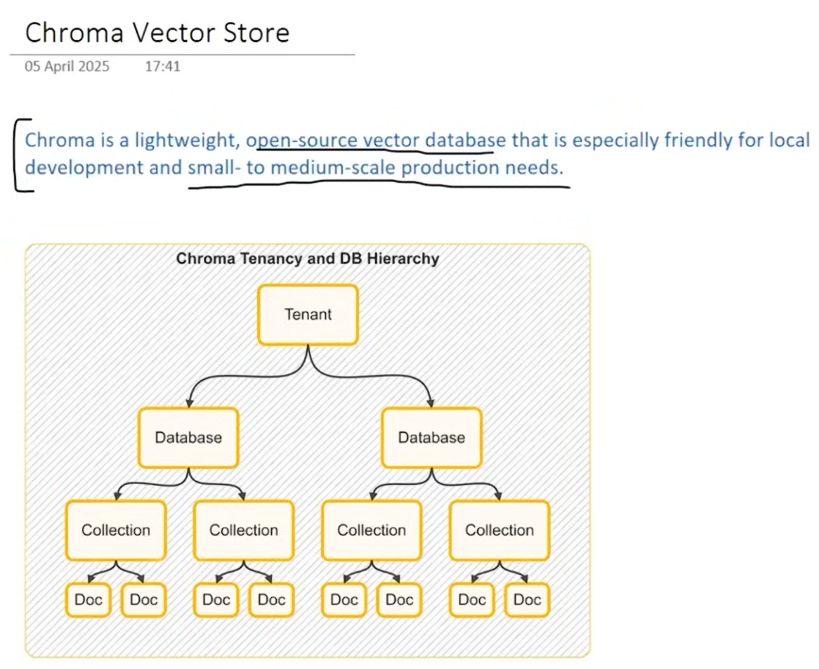

In [1]:
!pip install langchain chromadb openai tiktoken pypdf langchain_openai langchain-community

INFO: pip is looking at multiple versions of langchain-community to determine which version is compatible with other requirements. This could take a while.
   ---------------------------------------- 0.0/948.6 kB ? eta -:--:--
   --------------------------------- ------ 786.4/948.6 kB 4.2 MB/s eta 0:00:01
   ---------------------------------------- 948.6/948.6 kB 3.4 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.5 MB ? eta -:--:--
   ---- ----------------------------------- 0.3/2.5 MB ? eta -:--:--
   ---------------- ----------------------- 1.0/2.5 MB 2.8 MB/s eta 0:00:01
   ---------------- ----------------------- 1.0/2.5 MB 2.8 MB/s eta 0:00:01
   -------------------- ------------------- 1.3/2.5 MB 1.5 MB/s eta 0:00:01
   ---------------------------- ----------- 1.8/2.5 MB 1.7 MB/s eta 0:00:01
   --------------------------------- ------ 2.1/2.5 MB 1.7 MB/s eta 0:00:01
   ------------------------------------- -- 2.4/2.5 MB 1.5 MB/s eta 0:00:01
   ----------------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langchain-classic 1.0.1 requires langchain-core<2.0.0,>=1.2.5, but you have langchain-core 0.3.83 which is incompatible.
langchain-classic 1.0.1 requires langchain-text-splitters<2.0.0,>=1.1.0, but you have langchain-text-splitters 0.3.11 which is incompatible.
langchain-experimental 0.4.1 requires langchain-community<1.0.0,>=0.4.0, but you have langchain-community 0.3.31 which is incompatible.
langchain-experimental 0.4.1 requires langchain-core<2.0.0,>=1.0.0, but you have langchain-core 0.3.83 which is incompatible.
langchain-huggingface 0.3.1 requires huggingface-hub>=0.33.4, but you have huggingface-hub 0.30.2 which is incompatible.


In [2]:
from langchain_openai import OpenAIEmbeddings
from langchain.vectorstores import Chroma
from langchain.schema import Document

In [3]:
doc1 = Document(
    page_content = "Babar Azam is a Pakistani cricketer who has represented Pakistan in all formats of the game. He is a right-handed batsman and occasional wicket-keeper. Azam made his international debut for Pakistan in 2015 and has since become one of the team's key players. He has scored several centuries and half-centuries in international cricket and is known for his elegant batting style.",
    metadata = {"team" : "Pakistan"}

)
doc2 = Document(
        page_content="Rohit Sharma is the most successful captain in IPL history, leading Mumbai Indians to five titles. He's known for his calm demeanor and ability to play big innings under pressure.",
        metadata={"team": "Mumbai Indians"}
    )
doc3 = Document(
        page_content="MS Dhoni, famously known as Captain Cool, has led Chennai Super Kings to multiple IPL titles. His finishing skills, wicketkeeping, and leadership are legendary.",
        metadata={"team": "Chennai Super Kings"}
    )
doc4 = Document(
        page_content="Jasprit Bumrah is considered one of the best fast bowlers in T20 cricket. Playing for Mumbai Indians, he is known for his yorkers and death-over expertise.",
        metadata={"team": "Mumbai Indians"}
    )
doc5 = Document(
        page_content="Ravindra Jadeja is a dynamic all-rounder who contributes with both bat and ball. Representing Chennai Super Kings, his quick fielding and match-winning performances make him a key player.",
        metadata={"team": "Chennai Super Kings"}
    )

In [4]:
vector_store= Chroma(
    embedding_function = OpenAIEmbeddings(),
    persist_directory = "vector_store_data",
    collection_name = "cricket_players"
)

C:\Users\Sikandar\AppData\Local\Temp\ipykernel_18484\1213033138.py:1: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-chroma package and should be used instead. To use it run `pip install -U :class:`~langchain-chroma` and import as `from :class:`~langchain_chroma import Chroma``.
  vector_store= Chroma(


In [5]:
vector_store.add_documents([doc1, doc2, doc3, doc4, doc5])

['6a70a0c4-e7f5-4ce0-96cf-7c6f5b8a5c5b',
 '4e153889-218c-4cc8-b92e-61fd79be275e',
 '2508166b-f820-496f-9e7c-53bac4b4291f',
 '3177f404-49bb-4566-836b-2801d4e8b7e0',
 'd943ab76-2ccd-43c1-82fc-be1fb3c1117d']

In [7]:
vector_store.get(include = ['embeddings', 'metadatas', 'documents'])

{'ids': ['6a70a0c4-e7f5-4ce0-96cf-7c6f5b8a5c5b',
  '4e153889-218c-4cc8-b92e-61fd79be275e',
  '2508166b-f820-496f-9e7c-53bac4b4291f',
  '3177f404-49bb-4566-836b-2801d4e8b7e0',
  'd943ab76-2ccd-43c1-82fc-be1fb3c1117d'],
 'embeddings': array([[-2.27469523e-02, -1.59052908e-02,  2.15292629e-02, ...,
          9.86705534e-03, -2.03241259e-02, -2.45923176e-02],
        [-2.70681921e-03, -5.47363961e-05,  2.82030534e-02, ...,
         -1.50933377e-02,  5.93815418e-03, -1.16601437e-02],
        [ 7.83727213e-04, -4.76402277e-03,  1.23708826e-02, ...,
         -1.72387529e-02,  7.74397107e-04,  2.93532619e-03],
        [-2.71391869e-02,  8.87096301e-03,  2.69362777e-02, ...,
         -2.58583203e-02,  9.02314577e-03, -1.99992992e-02],
        [-1.81433018e-02,  1.27527108e-02,  3.47932205e-02, ...,
         -3.03654689e-02, -5.85236121e-03,  5.21374308e-03]],
       shape=(5, 1536)),
 'documents': ["Babar Azam is a Pakistani cricketer who has represented Pakistan in all formats of the game. He 

In [9]:
vector_store.similarity_search(
    query = "Who among these are a bowler?",
    k = 2
)

[Document(metadata={'team': 'Mumbai Indians'}, page_content='Jasprit Bumrah is considered one of the best fast bowlers in T20 cricket. Playing for Mumbai Indians, he is known for his yorkers and death-over expertise.'),
 Document(metadata={'team': 'Chennai Super Kings'}, page_content='Ravindra Jadeja is a dynamic all-rounder who contributes with both bat and ball. Representing Chennai Super Kings, his quick fielding and match-winning performances make him a key player.')]

In [10]:
# Jitna km otna acha
vector_store.similarity_search_with_score(
    query = "Who among these are a bowler?",
    k = 2
)

[(Document(metadata={'team': 'Mumbai Indians'}, page_content='Jasprit Bumrah is considered one of the best fast bowlers in T20 cricket. Playing for Mumbai Indians, he is known for his yorkers and death-over expertise.'),
  0.35432544350624084),
 (Document(metadata={'team': 'Chennai Super Kings'}, page_content='Ravindra Jadeja is a dynamic all-rounder who contributes with both bat and ball. Representing Chennai Super Kings, his quick fielding and match-winning performances make him a key player.'),
  0.4086669683456421)]

In [11]:
vector_store.similarity_search(
    query = "",
    filter = {"team" : "Mumbai Indians"},
)

[Document(metadata={'team': 'Mumbai Indians'}, page_content="Rohit Sharma is the most successful captain in IPL history, leading Mumbai Indians to five titles. He's known for his calm demeanor and ability to play big innings under pressure."),
 Document(metadata={'team': 'Mumbai Indians'}, page_content='Jasprit Bumrah is considered one of the best fast bowlers in T20 cricket. Playing for Mumbai Indians, he is known for his yorkers and death-over expertise.')]

In [12]:
# update documents
updated_doc1 = Document(
    page_content="Virat Kohli, the former captain of Royal Challengers Bangalore (RCB), is renowned for his aggressive leadership and consistent batting performances. He holds the record for the most runs in IPL history, including multiple centuries in a single season. Despite RCB not winning an IPL title under his captaincy, Kohli's passion and fitness set a benchmark for the league. His ability to chase targets and anchor innings has made him one of the most dependable players in T20 cricket.",
    metadata={"team": "Royal Challengers Bangalore"}
)

vector_store.update_document(document_id='09a39dc6-3ba6-4ea7-927e-fdda591da5e4', document=updated_doc1)


In [13]:
vector_store.get(include=['embeddings','documents', 'metadatas'])

{'ids': ['6a70a0c4-e7f5-4ce0-96cf-7c6f5b8a5c5b',
  '4e153889-218c-4cc8-b92e-61fd79be275e',
  '2508166b-f820-496f-9e7c-53bac4b4291f',
  '3177f404-49bb-4566-836b-2801d4e8b7e0',
  'd943ab76-2ccd-43c1-82fc-be1fb3c1117d'],
 'embeddings': array([[-2.27469523e-02, -1.59052908e-02,  2.15292629e-02, ...,
          9.86705534e-03, -2.03241259e-02, -2.45923176e-02],
        [-2.70681921e-03, -5.47363961e-05,  2.82030534e-02, ...,
         -1.50933377e-02,  5.93815418e-03, -1.16601437e-02],
        [ 7.83727213e-04, -4.76402277e-03,  1.23708826e-02, ...,
         -1.72387529e-02,  7.74397107e-04,  2.93532619e-03],
        [-2.71391869e-02,  8.87096301e-03,  2.69362777e-02, ...,
         -2.58583203e-02,  9.02314577e-03, -1.99992992e-02],
        [-1.81433018e-02,  1.27527108e-02,  3.47932205e-02, ...,
         -3.03654689e-02, -5.85236121e-03,  5.21374308e-03]],
       shape=(5, 1536)),
 'documents': ["Babar Azam is a Pakistani cricketer who has represented Pakistan in all formats of the game. He 